In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional for interactive charts
import plotly.express as px

sns.set(style="whitegrid")

In [2]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Remove null values
df = df.dropna()

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Total Price column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [27]:
total_revenue = df['TotalPrice'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Revenue: 8911407.904
Total Orders: 18536
Total Customers: 4339


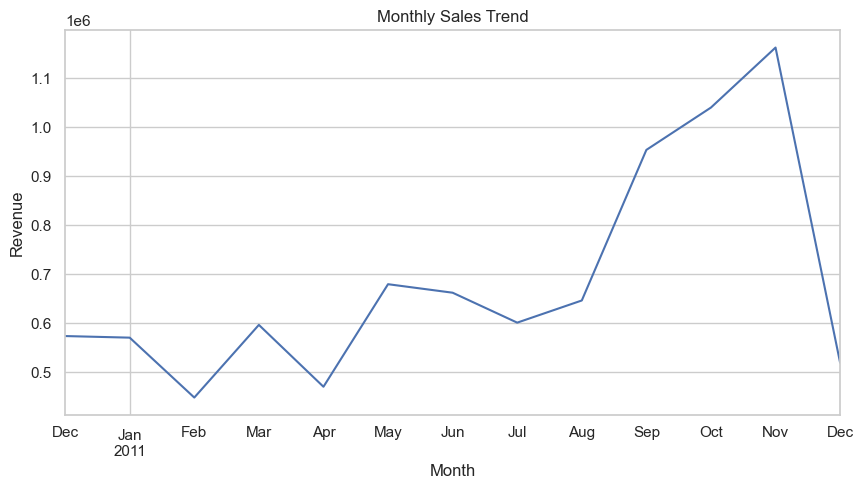

In [28]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

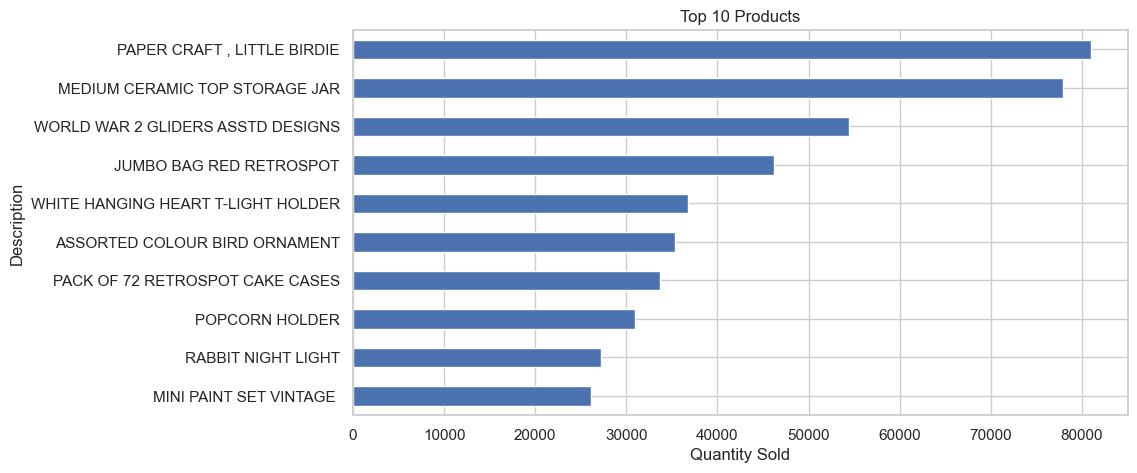

In [29]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values().tail(10)

top_products.plot(kind='barh', figsize=(10,5))
plt.title("Top 10 Products")
plt.xlabel("Quantity Sold")
plt.show()

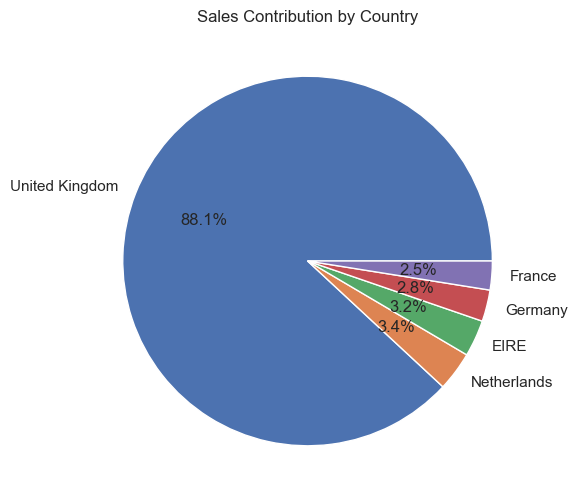

In [30]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(5)

country_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Sales Contribution by Country")
plt.ylabel('')
plt.show()

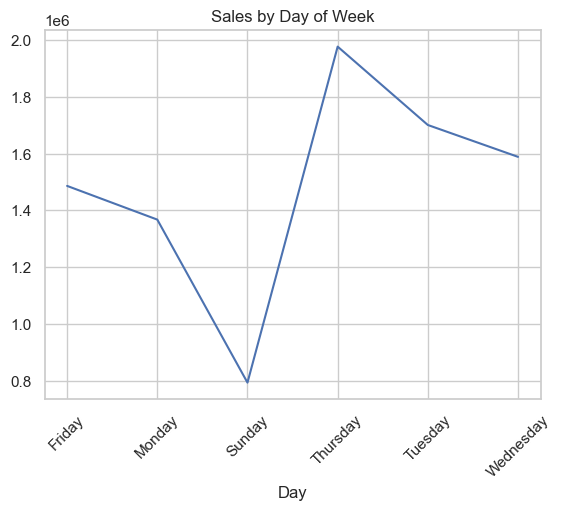

In [31]:
df['Day'] = df['InvoiceDate'].dt.day_name()

day_sales = df.groupby('Day')['TotalPrice'].sum()

sns.lineplot(x=day_sales.index, y=day_sales.values)
plt.xticks(rotation=45)
plt.title("Sales by Day of Week")
plt.show()

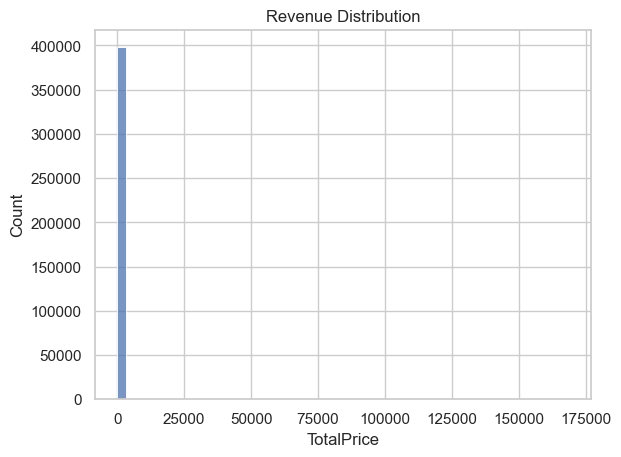

In [32]:
sns.histplot(df['TotalPrice'], bins=50)
plt.title("Revenue Distribution")
plt.show()

In [43]:
import datetime as dt

latest_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()  

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [45]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4], duplicates='drop')
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4], duplicates='drop')

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,4,114
12347.0,1,182,4310.00,4,4,4,444
12348.0,74,31,1797.24,2,2,4,224
12349.0,18,73,1757.55,3,3,4,334
12350.0,309,17,334.40,1,1,2,112


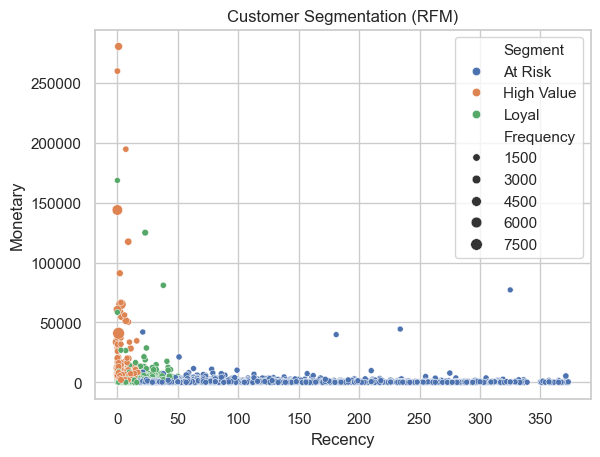

In [37]:
sns.scatterplot(data=rfm,
                x='Recency',
                y='Monetary',
                size='Frequency',
                hue='Segment')

plt.title("Customer Segmentation (RFM)")
plt.show()

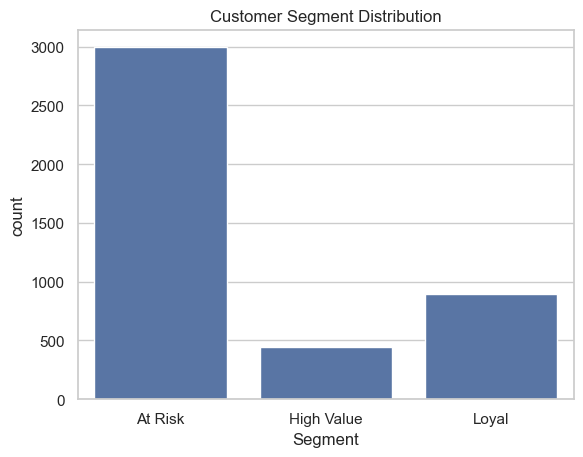

In [38]:
sns.countplot(data=rfm, x='Segment')
plt.title("Customer Segment Distribution")
plt.show()

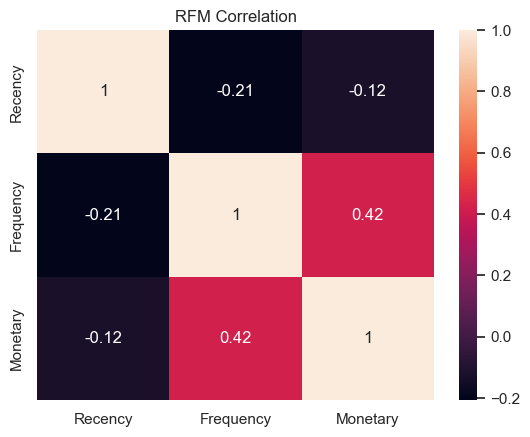

In [39]:
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True)
plt.title("RFM Correlation")
plt.show()